In [ ]:
from preparations.network import net
netObj = net(f'ckpts\dlv3p_rgb_3.pth')
# netObj.model.eval()

True


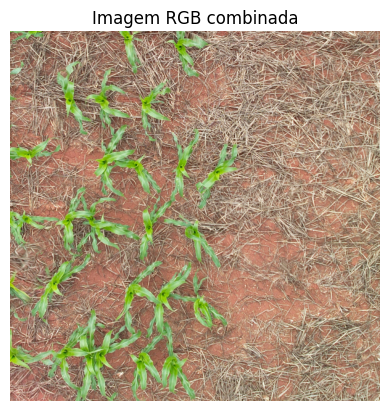

Shape da saída: (1, 3, 600, 600)
Valores mínimos e máximos: -11.856975 8.835159


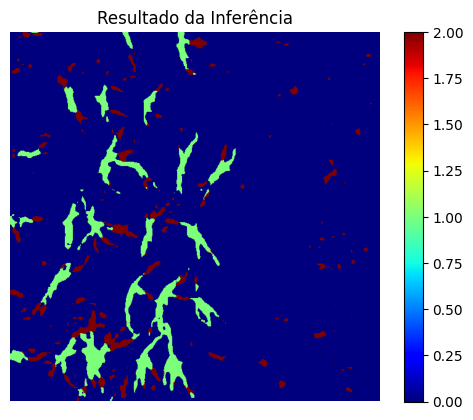

In [ ]:
image_path = '/Imgs/12_image_flip_hv_rot180.png'
print('getLayersFromImage' in dir(net))
netObj.inferencia_modelo_by_RGB(image_path)


In [ ]:
import os
import cv2
import numpy as np

path = '/imgs/dataArgumentation'

# Criando listas de imagens e máscaras
train = []
mask = []

for image_path in os.listdir(path):
    if image_path.endswith('png') and 'image' in image_path:
        full_image_path = os.path.join(path, image_path)
        full_mask_path = full_image_path.replace('image', 'predict')

        image = cv2.cvtColor(cv2.imread(full_image_path), cv2.COLOR_BGR2RGB)
        mask_image = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)

        train.append(image)
        mask.append(mask_image)

# Convertendo listas para arrays do NumPy
train = np.array(train)
mask = np.array(mask)

print(f"Total de imagens carregadas: {len(train)}")
print(f"Formato de uma imagem: {train[0].shape} (se não estiver vazia)")
print(f"Formato de uma máscara: {mask[0].shape} (se não estiver vazia)")


Total de imagens carregadas: 1184
Formato de uma imagem: (600, 600, 3) (se não estiver vazia)
Formato de uma máscara: (1000, 1000) (se não estiver vazia)


In [7]:
from sklearn.model_selection import train_test_split

# Dividir os dados em 80% treino e 20% validação
train_data, val_data, train_mask, val_mask = train_test_split(
    train, mask, test_size=0.2, random_state=42
)

In [9]:
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import torch

class DatasetMilho(Dataset):
    def __init__(self, imagens, mascaras, transform=None):
        self.imagens = imagens
        self.mascaras = mascaras
        self.transform = transform

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, index):
        # Carregar a imagem e a máscara
        image = self.imagens[index]
        mask = self.mascaras[index]

        # Aplica a transformação nas imagens e máscaras, se fornecido
        if self.transform:
            image = self.transform(image)
            # Se a máscara for uma imagem (com valores binários ou de classe), não deve ser normalizada
            # Caso contrário, a máscara será transformada diretamente em um tensor sem normalização
            mask = torch.tensor(mask, dtype=torch.long)  # Usar long para máscaras de segmentação (valores inteiros)

        return image, mask

# Definindo a transformação ToTensor() para as imagens
transform = transforms.Compose([
    transforms.ToTensor(),  # Converte a imagem para tensor (C, H, W)
])

# Exemplo de como criar o dataset
DatasetTreino = DatasetMilho(train_data, train_mask, transform=transform)
DatasetValidacao = DatasetMilho(val_data, val_mask, transform=transform)

# Criando DataLoader para treino e validação
train_loader = DataLoader(DatasetTreino, batch_size=4, shuffle=True)
val_loader = DataLoader(DatasetValidacao, batch_size=4, shuffle=False)


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# Garantir que o modelo esteja no dispositivo correto (GPU ou CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inicializando o modelo (já carregado em netObj.model ou similar)
model = netObj.model.to(device)  # Se o modelo foi carregado corretamente

# Definindo a função de perda e o otimizador
criterion = nn.CrossEntropyLoss()  # Perda para tarefas de segmentação
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Número de épocas para o treinamento
num_epochs = 10  # Ajuste conforme necessário

# Listas para armazenar as perdas de treinamento e validação ao longo das épocas
train_losses = []
val_losses = []

# Loop de treinamento
for epoch in range(num_epochs):
    model.train()  # Coloca o modelo em modo de treinamento
    running_loss = 0.0  # Variável para armazenar a perda acumulada

    # Loop para iterar pelo DataLoader de treino
    for images, masks in tqdm(train_loader, desc=f'Treinando Epoch {epoch+1}/{num_epochs}', unit="batch"):
        images = images.to(device)
        masks = masks.to(device)

        # Zero os gradientes do otimizador
        optimizer.zero_grad()

        # Realiza a passagem para frente (inferência)
        outputs = model(images)['out']  # Saída do modelo (provavelmente um dicionário com chave 'out')

        # Calcula a perda entre as previsões (outputs) e as máscaras reais
        loss = criterion(outputs, masks)
        loss.backward()  # Retropropaga a perda

        # Atualiza os pesos do modelo
        optimizer.step()

        # Acumula a perda para imprimir no final da época
        running_loss += loss.item()

    # Adiciona a perda média de treinamento da época à lista
    train_losses.append(running_loss / len(train_loader))

    # Imprime a perda média da época
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}")

    # Validação após cada época (opcional)
    model.eval()  # Coloca o modelo em modo de avaliação
    val_loss = 0.0

    with torch.no_grad():  # Desabilita o cálculo de gradientes para otimizar a memória durante a validação
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            # Passagem para frente para prever as máscaras
            outputs = model(images)['out']

            # Calcula a perda
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    # Adiciona a perda média de validação da época à lista
    val_losses.append(val_loss / len(val_loader))

    print(f"Validation Loss after Epoch {epoch+1}: {val_losses[-1]:.4f}")

# Plotando o gráfico de perdas de treinamento e validação
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Treinamento', color='blue', linestyle='-', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validação', color='red', linestyle='-', marker='x')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.title('Perda de Treinamento e Validação ao Longo das Épocas')
plt.legend()
plt.grid(True)
plt.show()

# Salvar o modelo treinado após o fine-tuning
torch.save(model.state_dict(), '/content/drive/MyDrive/milhoDaninhaSegmentant.pth')

print('Treinamento concluído e modelo salvo em /content/drive/MyDrive/milhoDaninhaSegmentant.pth')


Treinando Epoch 1/10:   0%|          | 0/237 [00:00<?, ?batch/s]